Jupyter notebook to test out using MAE trained on only 5 alongshore transects on either side of the prediction transect. One in the top of DEM and one in the bottom half. 

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

In [45]:
# paths
MAE_datapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data"
rawdatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/Transect_y7_3/2yavg/transects_7.3_2.mat"
traindatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/1702827001820_transects.mat" # change this
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration1"

In [46]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe
print(transect_df_raw.shape)

(551, 239)


In [47]:
raw_mat=loadmat(traindatapath)
train_struct=raw_mat['all_trans_struct']

all_trans=[]
names=[]

for elem in train_struct.ravel():
    name=elem['name'].item()
    data_matrix=elem['data']

    temp_df=pd.DataFrame(data_matrix)
    temp_df['name']=name

    all_trans.append(temp_df)
    names.append(name)

        
train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
train_ds=train_trans_df.drop(columns=['name'])
print("Dataset Shape:", train_ds.shape)
print("\nFirst few rows of the Transect Dataframe:")
print(train_ds.head())


Dataset Shape: (23142, 239)

First few rows of the Transect Dataframe:
                              0    1    2    3    4    5    6    7    8    \
transect_name original_index                                                
transect_y-60 0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

                              9    ...  229  230  231  232  233  234  235  \
transect_name original_index       ...                                      
transect_y-60 0               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              1               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              2               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    

In [48]:
# need to make transect and training data normalized on the same scale
from sklearn.preprocessing import MinMaxScaler
global_scaler=MinMaxScaler()
combined_raw_data=pd.concat([transect_df_raw,train_ds],axis=0)
global_scaler.fit(combined_raw_data.values.reshape(-1,1))
#function to transform ds
def scale_dataframe(df,fitted_scalar):
    scaled_matrix=df.values.copy()
    gaps_mask=np.isnan(scaled_matrix)

    flat_vals=scaled_matrix.reshape(-1,1)
    flat_vals[~np.isnan(flat_vals)]=fitted_scalar.transform(flat_vals[~np.isnan(flat_vals)].reshape(-1,1)).flatten()
    scaled_df=pd.DataFrame(flat_vals.reshape(df.shape),columns=df.columns,index=df.index)
    return scaled_df

train_df_norm=scale_dataframe(train_ds,global_scaler)
train_df_norm_nodune=train_df_norm.iloc[200:,:]

transect_73=scale_dataframe(transect_df_raw,global_scaler)
transect_73_nodune=transect_73.iloc[200:,:]
#transect_df_norm=scale_dataframe(transect_df_raw,global_scaler)
#transect_df_norm_nodune=transect_df_norm[200:]
#train_df_norm=scale_dataframe(train_ds,global_scaler)
#train_df_norm_nodune=train_df_norm[200:]

In [49]:
def unscale_dataframe(df, fitted_scalar):
    # Retrieve original values
    scaled_matrix = df.values 
    
    # Inverse transform the entire matrix (NaNs are ignored by the scaler automatically)
    unscaled_matrix = fitted_scalar.inverse_transform(scaled_matrix)
    
    # Reconstruct the DataFrame
    unscaled_df = pd.DataFrame(unscaled_matrix, columns=df.columns, index=df.index)
    
    return unscaled_df

In [50]:
print(transect_73_nodune.shape)

(351, 239)


functions

In [51]:
def is_gap_too_big(mask,window_size):
    mask_str="".join(mask.astype(int).astype(str))
    return "0"*window_size in mask_str

In [52]:
# define model
class Denoise(Model):
    def __init__(self,window_size):
        super(Denoise,self).__init__()
        self.window_size=window_size

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(window_size,2)), # changed from none
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Flatten(),
            layers.Dense(window_size,activation='sigmoid'),
            layers.Reshape((window_size,1))
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
    def train_step(self,data):
        # to get input tensor (x_input,y) from .map() in mask
        x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

        with tf.GradientTape() as tape: 
            # forward pass using x_masked
            y_pred=self(x_input,training=True)
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
           
        trainable_vars=self.trainable_variables
        gradients=tape.gradient(loss,trainable_vars)
        self.optimizer.apply_gradients(zip(gradients,trainable_vars))

        return{"loss":loss}
    
    def test_step(self,data):
         # to get input tensor
        x,y,mask,start_idx,t_step=data
 
        y_pred=self(x,training=False)
        mse=tf.square(y_pred-y) #calc loss
        masked_mse=mse*(1.0 - mask) # masked loss
        loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

        return {"loss":loss}

def gap_mask(x,mask_ratio):
     #batch_size=tf.shape(x)[0]
     length=tf.shape(x)[0]# number of things in x, x is (10,1)

     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window

     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     range_idx=tf.range(length) # (length,) 
     #boolean mask
     if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

     gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
     gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
     mask=1-gap_mask_tensor
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x,start,t_step):
    window_size=tf.shape(x)[0]
    x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))
    x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)
    return x_input,x, mask, start, t_step# (given data and target/real og data)


In [53]:
def prep_training(train_source_df,split_windows_idx,batch_size=16):
    # windows of training/testing/vaidation data
    # run MAE training cycle per targeted window size
    timesteps=sorted(split_windows_idx.keys()) #chronological order
    n=len(timesteps)

    # train/val/test bounds
    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=train_source_df[t].values #grab from static training source
            
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
    train_ds=build_ds(X_train,info_train)
    test_ds=build_ds(X_test,info_test)
    val_ds=build_ds(X_val,info_val)

    return train_ds, test_ds, val_ds

In [54]:
def run_MAE(window_size,train_ds,val_ds, epochs=20):
    # inirialize model
    model=Denoise(window_size=window_size)
    #optimizer_tuned=Adam(learning_rate=1e-4)
    model.compile(optimizer='adam')

    #print(f"Training started for window size: {window_size} (train shape: {train_ds.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history

In [55]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from left to right to impute where gaps exist
    # returns newly filled dataset
    x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
    transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps

    mask_matrix=active_mask_df.values.astype(np.float32)
    #raw_groundtruth=baseline_raw_df.values

    reconstructed_all=[]

    for i in range(tsteps): # loop through every time step
        x_1dim=x_matrix[:,i].numpy() #current transect
        mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
        #raw_1dim=raw_groundtruth[:,i] #true og data

        full_recon=np.zeros_like(x_1dim) 
        counts=np.zeros_like(x_1dim)

        # slide window over full transect profile
        for start in range(0,transect_pts-window_size+1,stride):
            end=start+window_size

            #window_raw=raw_1dim[start:end] # window of raw data
            window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
            window_mask=mask_1dim[start:end] #

            #model input shape
            combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim

            # check for too big of gap
            gap_too_big=is_gap_too_big(window_mask,window_size) 
            # check if window is full
            is_already_full = np.all(window_mask == 1.0)
            # check if the window has valid data on left and right edges
            has_bounded_edges = (window_mask[0] == 1.0) and (window_mask[-1] == 1.0)
            #double check there actually is a gap inside to fix (at least 1 point)
            has_gap_inside = np.any(window_mask == 0.0)

            # run MAE only if it's bounded on both sides
            if has_gap_inside and has_bounded_edges:
                #predict with MAE
                model_recon = model.predict(combined_input, verbose=0).flatten()
                # keep original data
                recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data

                #preds for avg
                full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                counts[start:end] += 1
            
            elif is_already_full:
                #keep full window
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1
        # trying to fix mismatch on gap edges
        raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
        nan_indices=np.isnan(raw_prediction)
        raw_prediction[nan_indices]=x_1dim[nan_indices]

        final_transect=raw_prediction.copy()
        is_gap=(mask_1dim==0) # find gap
        gap_changes=np.diff(is_gap.astype(int))

        gap_starts=np.where(gap_changes==1)[0]+1
        gap_ends=np.where(gap_changes==-1)[0]

        # at the edge
        if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
        if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
        # smooth over transistion?
        blend_zone=min(4,int(window_size/4)) # transistion blending margin

        for g_start,g_end in zip(gap_starts,gap_ends):
            #left side blend
            if g_start>blend_zone:
                anchor_val=x_1dim[g_start -1] #known real value
                for b in range(blend_zone):
                    idx=g_start+b
                    if idx<= g_end:
                        # linear transition (Could do something better) from anchor to pred
                        alpha=(b+1)/(blend_zone +1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            #right side
            if g_end< len(x_1dim)-blend_zone:
                anchor_val=x_1dim[g_end+1]
                for b in range(blend_zone):
                    idx=g_end-b
                    if idx>=g_start:
                        alpha=(b+1)/(blend_zone+1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]


        # avg overlapping windows
        #final_transect=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
        # keep anything if skipped
        #nan_indices=np.isnan(final_transect)
        #final_transect[nan_indices]=x_1dim[nan_indices]

        # overide to keep og data
        final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)

        reconstructed_all.append(final_transect)
    # return dataframe (points, timesteps)
    return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)


In [56]:
def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

In [57]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [58]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [59]:
# plotting functions
from matplotlib.animation import FuncAnimation
def save_stage_comparison_plots(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs"):
    """
    Plots and saves static comparisons showing the full profile (including dune),
    with the localized reconstructions overlaid at their proper positions.
    """
    os.makedirs(stage_dir, exist_ok=True)
    timesteps_to_plot = [0, 10, 20, 40, 60]
   
    # Define the spatial offset used during the .iloc[200:] slicing stage
    DUNE_OFFSET = 200
   
    for t in timesteps_to_plot:
        if t not in orig_full_df.columns:
            continue
           
        # 1. Grab the absolute raw baseline profile (including the dune)
        full_original = orig_full_df[t].values
        full_mask = ~np.isnan(full_original)
       
        # 2. Reconstruct the full coordinate line by stitching the original dune
        # together with the lower-beach patch provided by the current model stage
        full_reconstructed = full_original.copy()
       
        # Patch the trained window predictions over the lower-beach section
        # (This correctly aligns the model's indices starting from index 200 onward)
        full_reconstructed[DUNE_OFFSET:] = recon_no_dune_df[t].values

        plt.figure(figsize=(12, 4))
       
        # Plot the complete original line (dune + beach)
        plt.plot(full_original, color='blue', label='Original (with Dune)', alpha=0.8)
       
        # Overlay the reconstructed line
        plt.plot(full_reconstructed, color='deeppink', linewidth=2, linestyle='dashed',
                 label=f'Reconstructed (MAE-{window_size})')

        # Highlight missing gap regions across the entire profile layout
        plt.fill_between(
            np.arange(len(full_original)),
            np.nanmin(full_original) - 0.1,
            np.nanmax(full_original) + 0.1,
            where=~full_mask,
            color='gray',
            alpha=0.15,
            label='Missing Data Gap'
        )

        # Draw a vertical line denoting where the dune ends and the model zone begins
        plt.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.5, label='Dune Cutoff boundary')

        plt.title(f"Stage MAE-{window_size} Full Profile Reconstruction - Timestep {t}")
        plt.xlabel("Full Cross-shore index (Including Dune)")
        plt.ylabel("Normalized Elevation")
        plt.legend(loc='lower left')
        plt.tight_layout()
       
        # Save plot out
        plot_path = os.path.join(stage_dir, f"full_recon_stage_MAE{window_size}_timestep{t}.png")
        plt.savefig(plot_path, dpi=200)
        plt.close()


In [60]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    # gaps as highlights
    gap_spans=[]
    gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
    ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:, frame]

        is_gap=np.isnan(y_orig)
        is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

        if np.any(is_gap):
            diff=np.diff(is_gap.astype(int))
            gap_starts=np.where(diff==1)[0]+1
            gap_ends=np.where(diff==-1)[0]+1

            if is_gap[0]:
                gap_starts=np.insert(gap_starts,0,0)
            if is_gap[-1]:
                gap_ends=np.append(gap_ends,n_points-1)

            for start,end in zip(gap_starts, gap_ends):
                span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                gap_spans.append(span)

       
        line_recon.set_data(x_coords, y_recon_full)
        line_orig.set_data(x_coords, y_orig)
        #line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
        return [line_orig, line_recon] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

training

In [61]:
# QC training data (no values below zero)
train_ds[train_ds <0]=float('nan')
# normalize
#normalize training data

all_vals=train_ds.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

#train_df_norm=(train_ds-min_elev)/(max_elev-min_elev)

Minimum elev: 0.449 m
Max elev: 10.141384615384617 m


In [62]:
#Grab transects closest to 7.3 for training
targets = ['transect_y6', 'transect_y8.3','transect_y4','transect_y2','transect_y0','transect_y-2','transect_y10.3','transect_y12.3','transect_y14.3','transect_y16.3']
selected_transects = train_df_norm_nodune.query("transect_name in @targets")
print(selected_transects)

                               0    1    2    3    4    5    6    7    8    \
transect_name  original_index                                                
transect_y-2   0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...                            ...  ...  ...  ...  ...  ...  ...  ...  ...   
transect_y16.3 546             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               547             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               548             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               549             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               550             NaN  NaN  NaN  NaN  NaN  NaN  NaN

In [63]:
# find contnious windows of data for training ds
def what_window_sizes(df):
    lengths_per_col={}
    all_lengths=[]

    for col_name,col_data in df.items():
        arg=col_data.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)

        lengths=[s.stop -s.start for s in clumps]
        lengths_per_col[col_name]=lengths
        all_lengths.extend(lengths)

    return lengths_per_col, all_lengths
    

total windows found: 24034
shortest window: 1
longest window: 431


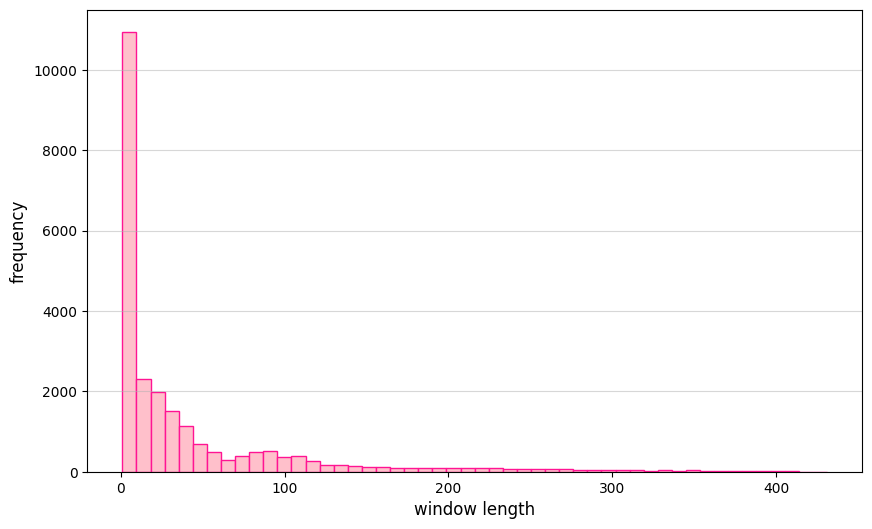

1. length: 11    frequency: 437
2. length: 21    frequency: 372
3. length: 22    frequency: 326
4. length: 30    frequency: 288
5. length: 17    frequency: 277


In [64]:
lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")


Epoch 1/30
7464/7464 [==============================] - 41s 5ms/step - loss: 2.4928e-04 - val_loss: 1.9533e-05
Epoch 2/30
7464/7464 [==============================] - 42s 6ms/step - loss: 4.2273e-05 - val_loss: 1.4795e-05
Epoch 3/30
7464/7464 [==============================] - 40s 5ms/step - loss: 4.4578e-05 - val_loss: 1.2846e-05
Epoch 4/30
7464/7464 [==============================] - 39s 5ms/step - loss: 3.5572e-05 - val_loss: 6.7773e-06
Epoch 5/30
7464/7464 [==============================] - 41s 5ms/step - loss: 2.7281e-05 - val_loss: 1.3159e-05
Epoch 6/30
7464/7464 [==============================] - 44s 6ms/step - loss: 3.0126e-05 - val_loss: 1.5082e-05
Epoch 7/30
7464/7464 [==============================] - 45s 6ms/step - loss: 2.2948e-05 - val_loss: 6.5194e-06
Epoch 8/30
7464/7464 [==============================] - 45s 6ms/step - loss: 2.3907e-05 - val_loss: 4.5691e-06
Epoch 9/30
7464/7464 [==============================] - 45s 6ms/step - loss: 2.2055e-05 - val_loss: 5.3936e-06
E

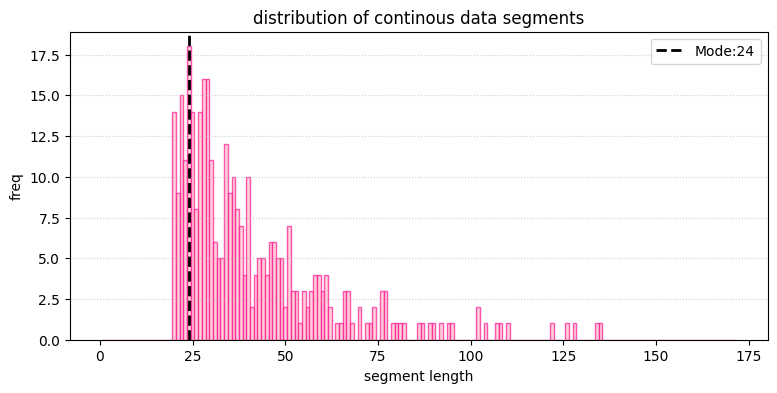

iteration done, moving to size 24
Epoch 1/30
2640/2640 [==============================] - 34s 13ms/step - loss: 3.8438e-04 - val_loss: 1.5326e-04
Epoch 2/30
2640/2640 [==============================] - 33s 13ms/step - loss: 4.4456e-05 - val_loss: 3.6723e-05
Epoch 3/30
2640/2640 [==============================] - 33s 13ms/step - loss: 4.5645e-05 - val_loss: 2.3182e-05
Epoch 4/30
2640/2640 [==============================] - 33s 13ms/step - loss: 3.2449e-05 - val_loss: 2.1696e-05
Epoch 5/30
2640/2640 [==============================] - 35s 13ms/step - loss: 3.1679e-05 - val_loss: 7.0103e-06
Epoch 6/30
2640/2640 [==============================] - 34s 13ms/step - loss: 3.6928e-05 - val_loss: 1.2284e-05
Epoch 7/30
2640/2640 [==============================] - 34s 13ms/step - loss: 2.3595e-05 - val_loss: 2.1079e-05
Epoch 8/30
2640/2640 [==============================] - 32s 12ms/step - loss: 2.9541e-05 - val_loss: 8.6184e-06
Epoch 9/30
2640/2640 [==============================] - 32s 12ms/step 

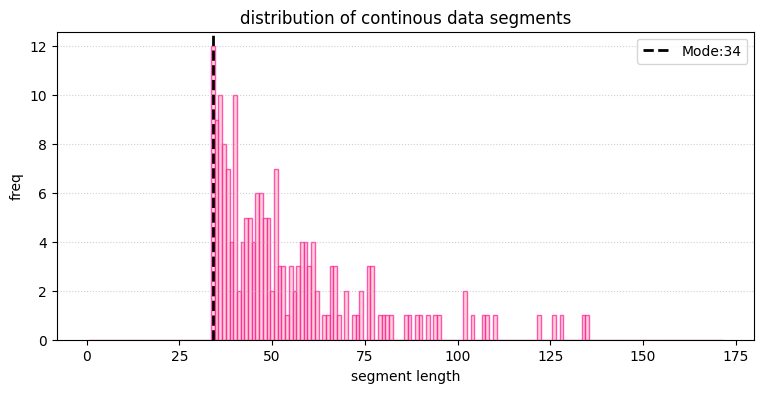

iteration done, moving to size 34
Epoch 1/30
1674/1674 [==============================] - 12s 6ms/step - loss: 5.3768e-04 - val_loss: 2.4506e-04
Epoch 2/30
1674/1674 [==============================] - 11s 6ms/step - loss: 1.2641e-04 - val_loss: 1.0066e-04
Epoch 3/30
1674/1674 [==============================] - 10s 6ms/step - loss: 5.4048e-05 - val_loss: 2.5108e-05
Epoch 4/30
1674/1674 [==============================] - 11s 6ms/step - loss: 4.1652e-05 - val_loss: 4.8534e-05
Epoch 5/30
1674/1674 [==============================] - 11s 7ms/step - loss: 3.5321e-05 - val_loss: 1.5583e-05
Epoch 6/30
1674/1674 [==============================] - 11s 7ms/step - loss: 3.1771e-05 - val_loss: 1.5836e-05
Epoch 7/30
1674/1674 [==============================] - 12s 7ms/step - loss: 3.2713e-05 - val_loss: 2.2478e-05
Epoch 8/30
1674/1674 [==============================] - 11s 6ms/step - loss: 2.9636e-05 - val_loss: 3.0700e-05
Epoch 9/30
1674/1674 [==============================] - 11s 6ms/step - loss: 2

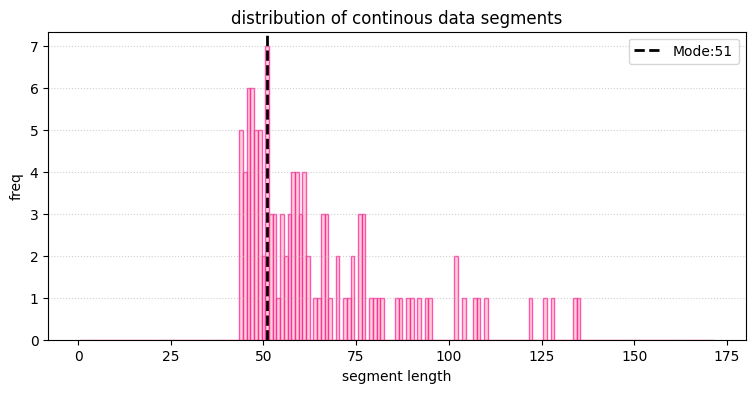

iteration done, moving to size 51
Epoch 1/30
963/963 [==============================] - 7s 6ms/step - loss: 5.0170e-04 - val_loss: 1.4079e-04
Epoch 2/30
963/963 [==============================] - 6s 6ms/step - loss: 1.2976e-04 - val_loss: 3.5602e-05
Epoch 3/30
963/963 [==============================] - 6s 6ms/step - loss: 5.7405e-05 - val_loss: 4.6913e-05
Epoch 4/30
963/963 [==============================] - 6s 6ms/step - loss: 4.6602e-05 - val_loss: 6.4711e-05
Epoch 5/30
963/963 [==============================] - 6s 6ms/step - loss: 3.8138e-05 - val_loss: 2.6851e-05
Epoch 6/30
963/963 [==============================] - 6s 6ms/step - loss: 3.1982e-05 - val_loss: 2.3374e-05
Epoch 7/30
963/963 [==============================] - 6s 7ms/step - loss: 2.8328e-05 - val_loss: 2.2480e-05
Epoch 8/30
963/963 [==============================] - 7s 7ms/step - loss: 3.1013e-05 - val_loss: 1.4508e-05
Epoch 9/30
963/963 [==============================] - 7s 7ms/step - loss: 2.9311e-05 - val_loss: 2.134

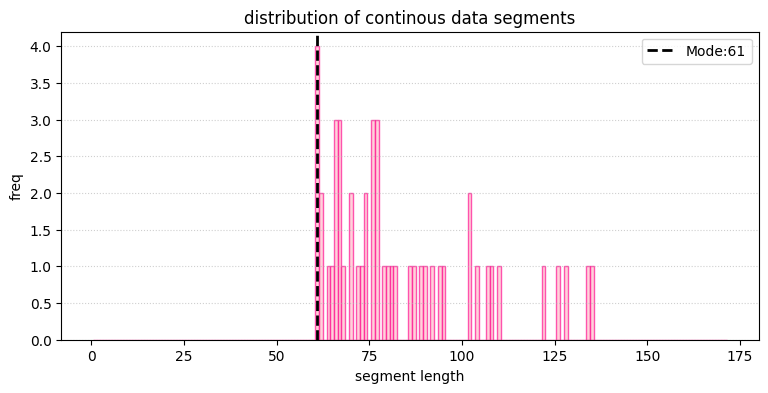

iteration done, moving to size 61
Epoch 1/30
724/724 [==============================] - 9s 11ms/step - loss: 6.0428e-04 - val_loss: 2.0199e-04
Epoch 2/30
724/724 [==============================] - 8s 11ms/step - loss: 1.9646e-04 - val_loss: 1.6994e-04
Epoch 3/30
724/724 [==============================] - 8s 11ms/step - loss: 1.1127e-04 - val_loss: 6.2749e-05
Epoch 4/30
724/724 [==============================] - 8s 11ms/step - loss: 5.6341e-05 - val_loss: 3.8557e-05
Epoch 5/30
724/724 [==============================] - 8s 11ms/step - loss: 4.4479e-05 - val_loss: 2.3315e-05
Epoch 6/30
724/724 [==============================] - 8s 11ms/step - loss: 5.0224e-05 - val_loss: 3.9307e-05
Epoch 7/30
724/724 [==============================] - 7s 10ms/step - loss: 4.8748e-05 - val_loss: 3.1473e-05
Epoch 8/30
724/724 [==============================] - 7s 10ms/step - loss: 4.5485e-05 - val_loss: 3.0469e-05
Epoch 9/30
724/724 [==============================] - 8s 11ms/step - loss: 4.9694e-05 - val_lo

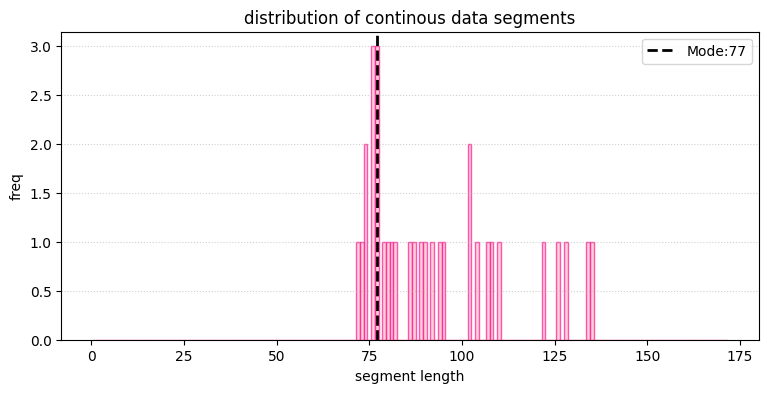

iteration done, moving to size 77
Epoch 1/30
503/503 [==============================] - 8s 14ms/step - loss: 6.9488e-04 - val_loss: 2.7424e-04
Epoch 2/30
503/503 [==============================] - 7s 14ms/step - loss: 1.8996e-04 - val_loss: 1.7940e-04
Epoch 3/30
503/503 [==============================] - 6s 13ms/step - loss: 1.9986e-04 - val_loss: 1.9378e-04
Epoch 4/30
503/503 [==============================] - 7s 14ms/step - loss: 1.7110e-04 - val_loss: 1.4947e-04
Epoch 5/30
503/503 [==============================] - 7s 14ms/step - loss: 1.1409e-04 - val_loss: 1.0367e-04
Epoch 6/30
503/503 [==============================] - 7s 13ms/step - loss: 6.5574e-05 - val_loss: 4.4367e-05
Epoch 7/30
503/503 [==============================] - 7s 13ms/step - loss: 5.1678e-05 - val_loss: 1.4988e-05
Epoch 8/30
503/503 [==============================] - 6s 13ms/step - loss: 5.8331e-05 - val_loss: 4.9623e-05
Epoch 9/30
503/503 [==============================] - 6s 12ms/step - loss: 4.8809e-05 - val_lo

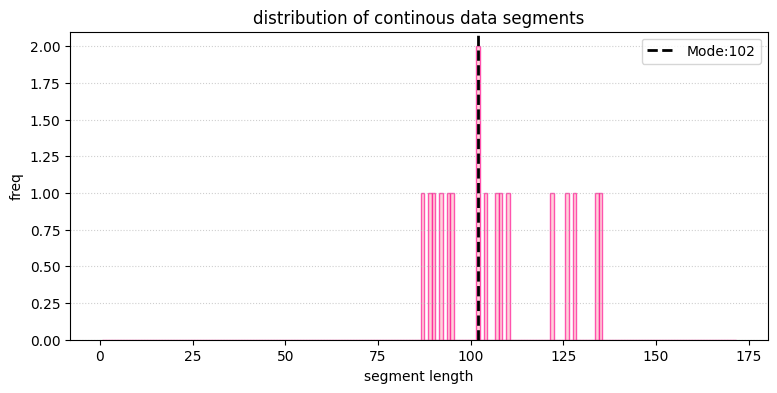

iteration done, moving to size 102
Epoch 1/30
297/297 [==============================] - 6s 17ms/step - loss: 8.8480e-04 - val_loss: 2.0786e-04
Epoch 2/30
297/297 [==============================] - 5s 17ms/step - loss: 1.9126e-04 - val_loss: 2.2520e-04
Epoch 3/30
297/297 [==============================] - 5s 17ms/step - loss: 1.9809e-04 - val_loss: 1.9181e-04
Epoch 4/30
297/297 [==============================] - 5s 17ms/step - loss: 1.9120e-04 - val_loss: 2.1828e-04
Epoch 5/30
297/297 [==============================] - 5s 16ms/step - loss: 1.9031e-04 - val_loss: 1.8187e-04
Epoch 6/30
297/297 [==============================] - 5s 16ms/step - loss: 1.7594e-04 - val_loss: 3.5235e-04
Epoch 7/30
297/297 [==============================] - 5s 17ms/step - loss: 1.6535e-04 - val_loss: 1.4433e-04
Epoch 8/30
297/297 [==============================] - 5s 16ms/step - loss: 1.4268e-04 - val_loss: 9.9023e-05
Epoch 9/30
297/297 [==============================] - 4s 15ms/step - loss: 9.7748e-05 - val_l

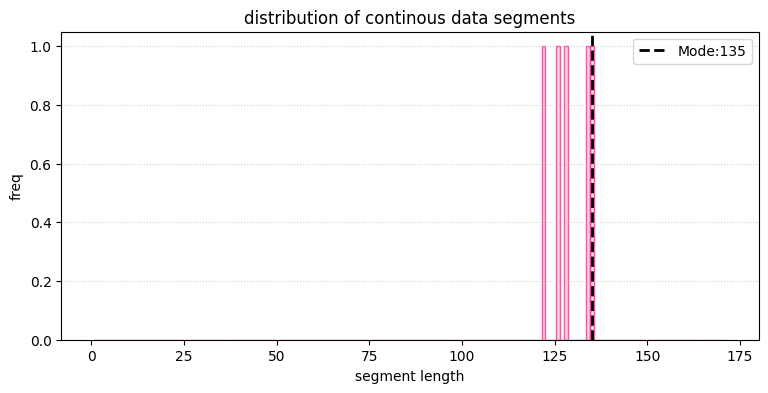

iteration done, moving to size 135
Epoch 1/30
167/167 [==============================] - 5s 25ms/step - loss: 0.0016 - val_loss: 2.2894e-04
Epoch 2/30
167/167 [==============================] - 4s 24ms/step - loss: 1.6437e-04 - val_loss: 2.0430e-04
Epoch 3/30
167/167 [==============================] - 4s 24ms/step - loss: 1.6234e-04 - val_loss: 2.3412e-04
Epoch 4/30
167/167 [==============================] - 4s 23ms/step - loss: 1.5379e-04 - val_loss: 2.7031e-04
Epoch 5/30
167/167 [==============================] - 4s 25ms/step - loss: 1.6954e-04 - val_loss: 2.1546e-04
Epoch 6/30
167/167 [==============================] - 4s 24ms/step - loss: 1.7566e-04 - val_loss: 2.9544e-04
Epoch 7/30
167/167 [==============================] - 4s 24ms/step - loss: 1.6170e-04 - val_loss: 2.4113e-04
Epoch 8/30
167/167 [==============================] - 4s 24ms/step - loss: 1.7489e-04 - val_loss: 3.9120e-04
Epoch 9/30
167/167 [==============================] - 4s 23ms/step - loss: 1.6053e-04 - val_loss:

In [65]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration3'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    #save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    #save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    


use most recent model (largest window size) to predict on transects, alternatively could try saving each model iteration and applying one by one

In [80]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from left to right to impute where gaps exist
    # returns newly filled dataset
    x_matrix = tf.convert_to_tensor(current_df.values, dtype=tf.float32)
    transect_pts, tsteps = x_matrix.shape
    mask_matrix = active_mask_df.values.astype(np.float32)

    reconstructed_all = []

    for i in range(tsteps):  # loop through every time step
        x_1dim = x_matrix[:, i].numpy()
        mask_1dim = mask_matrix[:, i]
        valid_indices = np.where(mask_1dim == 1.0)[0]
        last_valid_index = valid_indices[-1] if len(valid_indices) > 0 else -1

        # id real data
        final_transect=x_1dim.copy()
        full_recon = np.zeros_like(x_1dim)
        counts = np.zeros_like(x_1dim)

        # slide window over full transect profile
        for start in range(0, transect_pts - window_size + 1, stride):
            end = start + window_size
            window_data = np.nan_to_num(x_1dim[start:end])
            window_mask = mask_1dim[start:end]

            is_already_full = np.all(window_mask == 1.0)
            has_gap_inside = np.any(window_mask == 0.0)

            # PATH 1: Skip windows with no gaps (nothing to reconstruct)
            if is_already_full:
                continue

            # PATH 2: Predict gaps within window
            if has_gap_inside:
                gap_indices = np.where(window_mask == 0.0)[0]
                total_real_data_pts = np.sum(window_mask == 1.0)
                has_any_local_context = total_real_data_pts >= 1

                if is_gap_too_big(window_mask, window_size=window_size):
                    g_start = start + gap_indices[0]
                    while g_start > 0 and mask_1dim[g_start - 1] == 0.0:
                        g_start -= 1
                    g_end = start + gap_indices[-1]
                    while g_end < transect_pts - 1 and mask_1dim[g_end + 1] == 0.0:
                        g_end += 1
                    gap_size = g_end - g_start + 1
                    if gap_size > window_size:
                        continue

                has_bounds = (window_mask[0] == 1.0) and (window_mask[-1] == 1.0)
                left_bound = (window_mask[0] == 1.0) or (start > 0 and mask_1dim[start - 1] == 1.0)
                right_bound = (window_mask[-1] == 1.0) or (end < transect_pts and mask_1dim[end] == 1.0)
                is_bounded = (left_bound or right_bound) or has_bounds

                if has_any_local_context and is_bounded:
                    combined_input = np.stack([window_data, window_mask], axis=-1).reshape(1, window_size, 2)
                    model_recon = model.predict(combined_input, verbose=0).flatten()

                    # only model predictions inside gaps
                    is_gap_mask = (window_mask == 0.0)
                    full_recon[start:end] += np.where(is_gap_mask, model_recon, 0.0)
                    counts[start:end] += is_gap_mask.astype(float)

        # Average overlapping predictions in gaps
        raw_prediction = np.divide(
            full_recon, counts,
            out=np.full_like(full_recon, np.nan),
            where=counts > 0
        )

        # Remove extrapolation into the abyssal region beyond last valid measurement
        if last_valid_index != -1 and last_valid_index < len(raw_prediction) - 1:
            raw_prediction[last_valid_index + 1:] = np.nan

        #final_transect = raw_prediction.copy()

        # Smooth over gap transitions
        is_gap = (mask_1dim == 0)
        gap_changes = np.diff(is_gap.astype(int))
        gap_starts = np.where(gap_changes == 1)[0] + 1
        gap_ends = np.where(gap_changes == -1)[0]

        if is_gap[0]:
            gap_starts = np.insert(gap_starts, 0, 0)
        if is_gap[-1]:
            gap_ends = np.append(gap_ends, len(is_gap) - 1)

        blend_zone = min(4, int(window_size / 4))
        for g_start, g_end in zip(gap_starts, gap_ends):
            gap_pred=raw_prediction[g_start:g_end+1]
            if np.all(np.isnan(gap_pred)):
                continue
            current_gap_size = g_end - g_start + 1
            blended_gap=gap_pred.copy()

            if current_gap_size <= 6:
                continue
           
            # Left side blend
            if g_start > blend_zone:
                anchor_val = x_1dim[g_start - 1]
                for b in range(blend_zone):
                    idx = g_start + b
                    if idx <= g_end and not np.isnan(raw_prediction[idx]):
                        alpha = (b + 1) / (blend_zone + 1)
                        #final_transect[idx] = (1 - alpha) * anchor_val + alpha * raw_prediction[idx]
                        raw_prediction[idx]=(1 - alpha) * anchor_val + alpha *raw_prediction[idx]

            # Right side blend
            if g_end < len(x_1dim) - 1:
                right_anchor_idx = min(len(x_1dim) - 1, g_end + 1)
                if mask_1dim[right_anchor_idx] == 1.0:
                    anchor_val = x_1dim[g_end + 1]
                    for b in range(blend_zone):
                        idx = g_end - b
                        if idx >= g_start and not np.isnan(raw_prediction[idx]):
                            alpha = (b + 1) / (blend_zone + 1)
                            #final_transect[idx] = (1 - alpha) * anchor_val + alpha * raw_prediction[idx]
                            raw_prediction[idx] = (1 - alpha) * anchor_val + alpha * raw_prediction[idx]

        # Combine ground truth with filled gap predictions
        gap_idx_all=np.where(mask_1dim==0)[0]
        valid_preds=~np.isnan(raw_prediction[gap_idx_all])
        final_transect[gap_idx_all[valid_preds]]=raw_prediction[gap_idx_all[valid_preds]]
        #final_transect = np.where(mask_1dim == 1.0, x_1dim, final_transect)
        reconstructed_all.append(final_transect)

    return pd.DataFrame(np.stack(reconstructed_all, axis=1), columns=current_df.columns)

In [81]:
def predict_transect(model,transect_df,window_size,stride=5):
    # apply the most recent pre-trained model onto a new transect to predict values
    current_dataset=transect_df.copy()
    active_mask=(~np.isnan(current_dataset)).astype(float)

    reconstructed_df=reconstruct_ds_with_MAE(model=model,current_df=current_dataset,active_mask_df=active_mask,window_size=window_size,stride=stride)
    return reconstructed_df


alongshore_transects={transect_name:group.droplevel('transect_name')
                      for transect_name, group in train_df_norm.groupby(level='transect_name')}
print(f"{len(alongshore_transects)} transects in alongshore_transects")

import re
# sort transects
def extract_y_loc(name):
    match=re.search(r'y(-?\d+\.?d*)',name)
    if match:
        return float(match.group(1))
    return 0

sorted_alongshore_keys=sorted(alongshore_transects.keys(),key=extract_y_loc)
sorted_alongshore={k:alongshore_transects[k] for k in sorted_alongshore_keys}

42 transects in alongshore_transects


In [82]:
print(list(sorted_alongshore.keys()))

['transect_y-60', 'transect_y-58', 'transect_y-56', 'transect_y-54', 'transect_y-52', 'transect_y-50', 'transect_y-48', 'transect_y-46', 'transect_y-44', 'transect_y-42', 'transect_y-40', 'transect_y-38', 'transect_y-36', 'transect_y-34', 'transect_y-32', 'transect_y-30', 'transect_y-28', 'transect_y-26', 'transect_y-24', 'transect_y-22', 'transect_y-20', 'transect_y-18', 'transect_y-16', 'transect_y-14', 'transect_y-12', 'transect_y-10', 'transect_y-8', 'transect_y-6', 'transect_y-4', 'transect_y-2', 'transect_y0', 'transect_y2', 'transect_y4', 'transect_y6', 'transect_y8.3', 'transect_y10.3', 'transect_y12.3', 'transect_y14.3', 'transect_y16.3', 'transect_y18.3', 'transect_y20.3', 'transect_y22.3']


test on top half of the transects

In [83]:
subset_top={k:sorted_alongshore[k] for k in list(sorted_alongshore)[21:]}
print(list(subset_top.keys()))

['transect_y-18', 'transect_y-16', 'transect_y-14', 'transect_y-12', 'transect_y-10', 'transect_y-8', 'transect_y-6', 'transect_y-4', 'transect_y-2', 'transect_y0', 'transect_y2', 'transect_y4', 'transect_y6', 'transect_y8.3', 'transect_y10.3', 'transect_y12.3', 'transect_y14.3', 'transect_y16.3', 'transect_y18.3', 'transect_y20.3', 'transect_y22.3']


In [84]:
alongshore_predictions={}
final_model=trained_model # most recent iteration
final_window_size=final_model.window_size

savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/alongshore_preds/MAE_5neighbors/"

for t_name,df in subset_top.items():
    print(f"Predicting on transect: {t_name}")
    df_nodune=df.iloc[200:]
    reconstrcuted_df=predict_transect(model=final_model,transect_df=df_nodune,window_size=final_window_size,stride=5)
    alongshore_predictions[t_name]=reconstructed_df
    transect_savepath=os.path.join(savepath,"alongshore_preds",str(t_name))
    os.makedirs(transect_savepath,exist_ok=True)

    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=df, recon_no_dune_df=reconstructed_df,window_size=final_window_size,stage_dir=transect_savepath,interval=500)

Predicting on transect: transect_y-18
video of reconstruction
Predicting on transect: transect_y-16


KeyboardInterrupt: 